In [6]:
# Environment and Import
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys 
import os 
sys.path.append(os.path.abspath(os.path.join(os.getcwd(),"..")))
from src.yieldcurve import YieldCurve
print(sys.version)


3.14.3 (v3.14.3:323c59a5e34, Feb  3 2026, 11:41:37) [Clang 16.0.0 (clang-1600.0.26.6)]


In [7]:
import subprocess
subprocess.run(["pip", "install", "yfinance", "-q"])


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip3 install --upgrade pip


CompletedProcess(args=['pip', 'install', 'yfinance', '-q'], returncode=0)

## Yield Curve Data Source

Live US Treasury yields are sourced from Yahoo Finance via `yfinance`.
We use four benchmark maturities that represent key points on the curve:

| Ticker | Maturity | Instrument |
|--------|----------|------------|
| ^IRX   | 0.25 yr  | 13-week T-Bill |
| ^FVX   | 5 yr     | 5-year Treasury Note |
| ^TNX   | 10 yr    | 10-year Treasury Note |
| ^TYX   | 30 yr    | 30-year Treasury Bond |

Yields are returned as percentages and converted to decimals.
The `YieldCurve` class then interpolates between these points to
produce a smooth zero-rate curve across all maturities.

In [8]:
import yfinance as yf

# Fetch live US Treasury yield data from Yahoo Finance
# Yahoo Finance returns yields in %, divided by 100 to get decimals
treasury_tickers = {
    0.25: "^IRX",   # 13-week T-Bill
    5.0:  "^FVX",   # 5-year Treasury Note
    10.0: "^TNX",   # 10-year Treasury Note
    30.0: "^TYX",   # 30-year Treasury Bond
}

maturities = []
zero_rates = []

for maturity, ticker in sorted(treasury_tickers.items()):
    rate = yf.Ticker(ticker).history(period="1d")["Close"].iloc[-1] / 100
    maturities.append(maturity)
    zero_rates.append(round(rate, 5))
    print(f"  {maturity:.2f}yr -> {rate:.4%}  ({ticker})")

print(f"\nmaturities  = {maturities}")
print(f"zero_rates  = {zero_rates}")

  0.25yr -> 3.6030%  (^IRX)
  5.00yr -> 4.1240%  (^FVX)
  10.00yr -> 4.4630%  (^TNX)
  30.00yr -> 5.0310%  (^TYX)

maturities  = [0.25, 5.0, 10.0, 30.0]
zero_rates  = [np.float64(0.03603), np.float64(0.04124), np.float64(0.04463), np.float64(0.05031)]


In [ ]:
# Sanity checks on fetched yield data
assert len(maturities) == len(zero_rates), "Mismatch between maturities and rates"
assert all(0 < r < 0.15 for r in zero_rates), "Rates outside expected range (0-15%)"
assert maturities == sorted(maturities), "Maturities not in ascending order"

print("All sanity checks passed.")

In [9]:
# Create an instance of the YieldCurve class
curve = YieldCurve(
    maturities = maturities,
    zero_rates = zero_rates,
    compounding = "annual"
    )

In [10]:
# Sanity checks
test_maturities = [0.75, 3.0, 7.0]
for T in test_maturities:
    z = curve.get_zero_rate(T)
    d = curve.get_discount_factor(T)
    print(f"T = {T:.2f} years | Zero rate = {z:.2%} | Discount factor = {d:.2%}")

T = 0.75 years | Zero rate = 3.66% | Discount factor = 97.34%
T = 3.00 years | Zero rate = 3.90% | Discount factor = 89.14%
T = 7.00 years | Zero rate = 4.26% | Discount factor = 74.68%


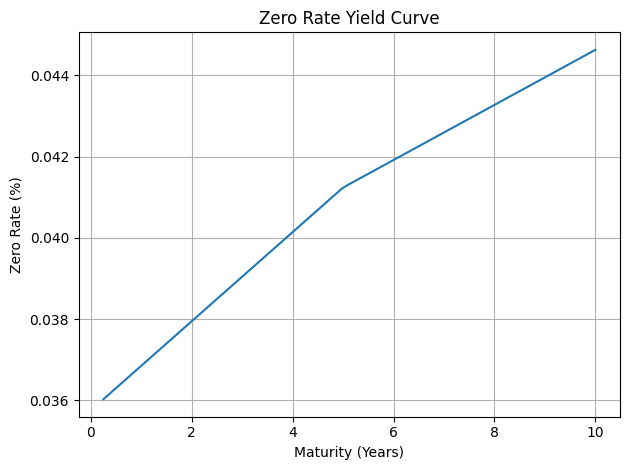

In [11]:
# Plot
curve.plot(max_maturity = 10)